In [2]:
import numpy as np
import matplotlib.pyplot as plt

from orbit_propagator import create_satellite_orbit, propagate_orbit

### Generating Satellite Orbit

In [3]:
orbit = create_satellite_orbit()

positions = propagate_orbit(orbit, minutes=90)

positions[:20]

array([[6878.1366    ,    0.        ,    0.        ],
       [6877.64325876,   41.18948145,   71.34227461],
       [6876.1633058 ,   82.37305419,  142.67431502],
       [6873.69695343,  123.54481034,  213.98588852],
       [6870.24455545,  164.69884375,  285.26676532],
       [6865.80660712,  205.82925077,  356.50672002],
       [6860.38374506,  246.93013118,  427.69553312],
       [6853.9767472 ,  287.99558896,  498.82299244],
       [6846.58653264,  329.0197332 ,  569.8788946 ],
       [6838.21416151,  369.9966789 ,  640.85304649],
       [6828.86083485,  410.92054784,  711.73526673],
       [6818.52789441,  451.7854694 ,  782.51538712],
       [6807.21682247,  492.58558142,  853.1832541 ],
       [6794.92924164,  533.31503106,  923.72873024],
       [6781.66691458,  573.96797559,  994.14169563],
       [6767.4317438 ,  614.53858326, 1064.41204941],
       [6752.22577138,  655.02103414, 1134.52971115],
       [6736.05117862,  695.40952093, 1204.48462232],
       [6718.91028583,  735.

### 3D Orbit Plot

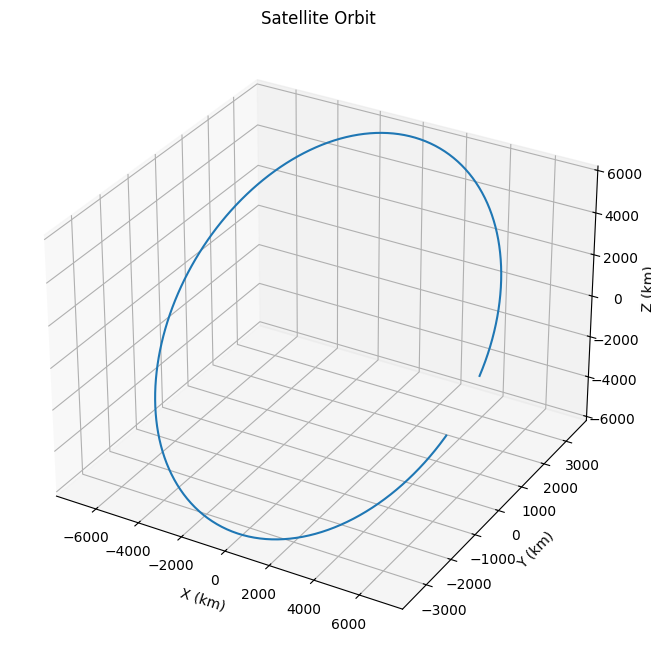

In [4]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

x = positions[:,0]
y = positions[:,1]
z = positions[:,2]

ax.plot(x, y, z)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")

ax.set_title("Satellite Orbit")

plt.show()

## Perhaps a cooler version (with our planet)

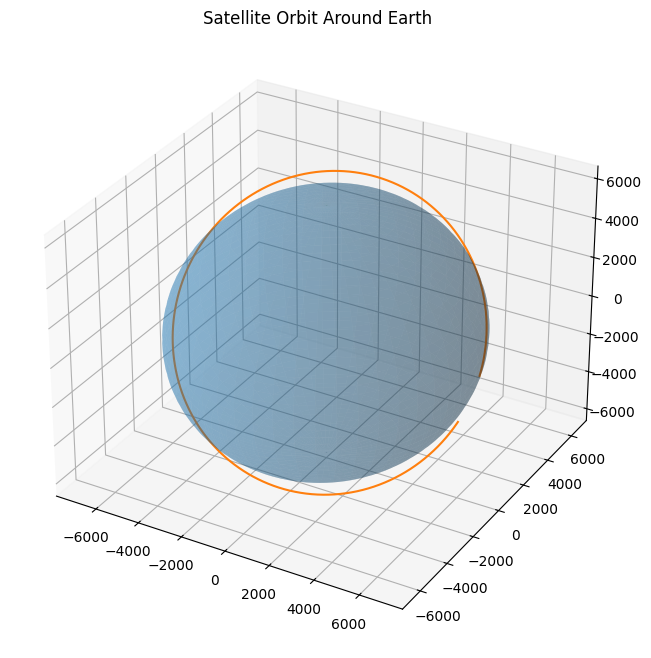

In [5]:
R = 6371

u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, np.pi, 100)

x_e = R * np.outer(np.cos(u), np.sin(v))
y_e = R * np.outer(np.sin(u), np.sin(v))
z_e = R * np.outer(np.ones(np.size(u)), np.cos(v))

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x_e, y_e, z_e, alpha=0.3)

ax.plot(x, y, z)

ax.set_title("Satellite Orbit Around Earth")

plt.show()

# Debris

In [6]:
from debris_generator import generate_debris

debris = generate_debris(50)

debris[:5]

[7076 x 7076 km x 26.6 deg orbit around Earth (♁),
 7458 x 7458 km x 169.7 deg orbit around Earth (♁),
 7533 x 7533 km x 155.3 deg orbit around Earth (♁),
 7089 x 7089 km x 7.6 deg orbit around Earth (♁),
 7435 x 7435 km x 10.6 deg orbit around Earth (♁)]

#### Simple Debris Positions

##### Right now our debris generator only stores orbital parameters - we also need positions, atleast for the visualisation purposes.

In [7]:
debris_positions = []

for _ in range(50):

    r = np.random.uniform(6800, 7500)

    theta = np.random.uniform(0, 2*np.pi)
    phi = np.random.uniform(0, np.pi)

    x = r*np.sin(phi)*np.cos(theta)
    y = r*np.sin(phi)*np.sin(theta)
    z = r*np.cos(phi)

    debris_positions.append([x,y,z])

debris_positions = np.array(debris_positions)

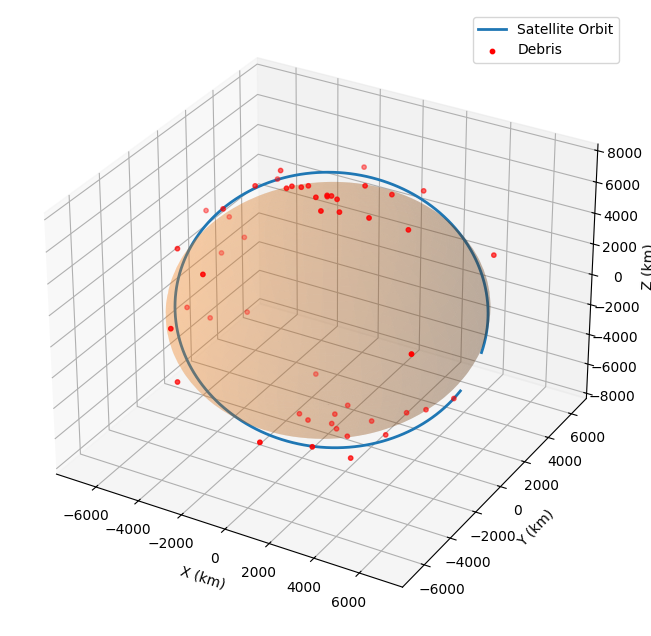

In [8]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# satellite orbit
sat_x = positions[:,0]
sat_y = positions[:,1]
sat_z = positions[:,2]

ax.plot(sat_x, sat_y, sat_z, linewidth=2, label="Satellite Orbit")

# debris
ax.scatter(
    debris_positions[:,0],
    debris_positions[:,1],
    debris_positions[:,2],
    color='red',
    s=10,
    label="Debris"
)

# Earth
ax.plot_surface(x_e, y_e, z_e, alpha=0.2)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")

ax.legend()

plt.show()

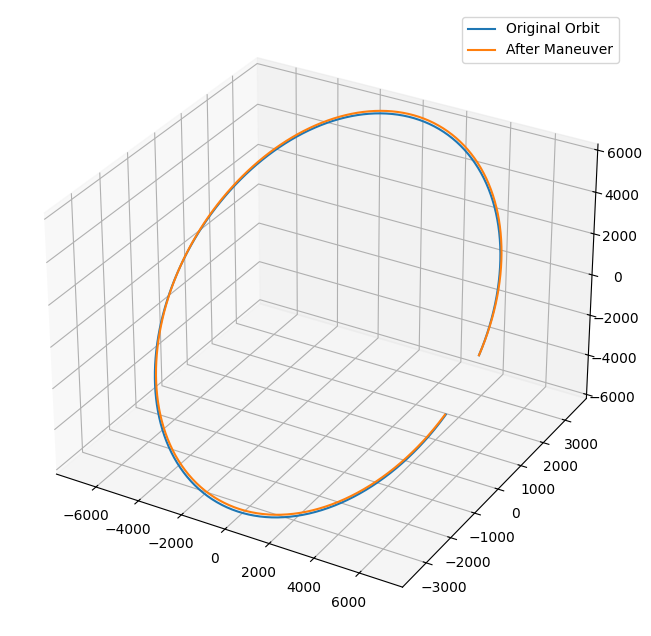

In [9]:
from satellite_maneuver import apply_maneuver
from astropy import units as u


#Creating delta v:

delta_v = np.array([0.1, 0, 0]) * u.km / u.s    #Need to make this significant to see any change.

new_orbit = apply_maneuver(orbit, delta_v)

old_positions = propagate_orbit(orbit)
new_positions = propagate_orbit(new_orbit)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(old_positions[:,0], old_positions[:,1], old_positions[:,2], label="Original Orbit")

ax.plot(new_positions[:,0], new_positions[:,1], new_positions[:,2], label="After Maneuver")

ax.legend()
plt.show()

In [10]:
#Testing time evolution

from debris_generator import generate_debris

debris_orbits = generate_debris(50)

debris_orbits[:3]

[6897 x 6897 km x 49.0 deg orbit around Earth (♁),
 6819 x 6819 km x 158.4 deg orbit around Earth (♁),
 7076 x 7076 km x 138.1 deg orbit around Earth (♁)]

In [11]:
#Debris Propagation:

from astropy import units as u

t = 30 * u.min

positions = []

for orbit in debris_orbits:

    new_orbit = orbit.propagate(t)
    positions.append(new_orbit.r.value)

positions = np.array(positions)

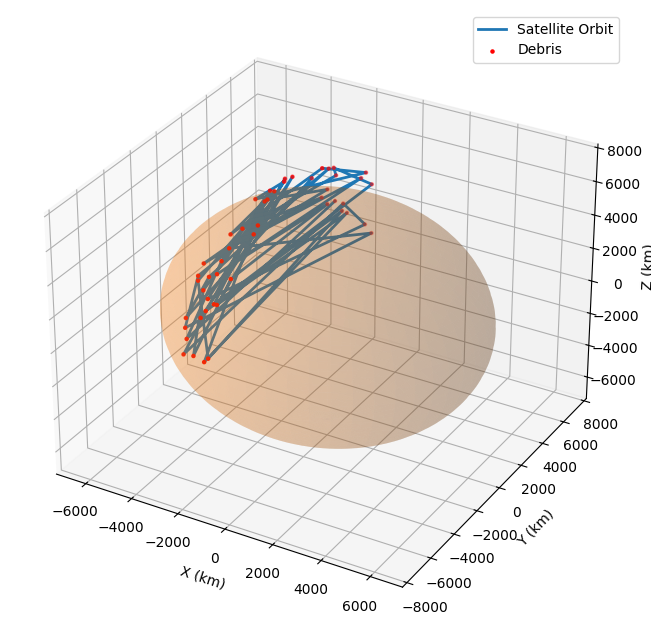

In [13]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# satellite orbit
sat_x = positions[:,0]
sat_y = positions[:,1]
sat_z = positions[:,2]

ax.plot(sat_x, sat_y, sat_z, linewidth=2, label="Satellite Orbit")

ax.scatter(
    positions[:,0],
    positions[:,1],
    positions[:,2],
    s=5,
    color="red",
    label="Debris"
)

# Earth
ax.plot_surface(x_e, y_e, z_e, alpha=0.2)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")

ax.legend()

plt.show()